In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/daily_raw.csv", parse_dates=["date"])
repas = pd.read_csv("../data/processed/repas_jour.csv", parse_dates=["date"])
df = df.merge(repas, on=["participant", "date"], how="left")

print(df.shape)
df.info()

(456, 47)
<class 'pandas.DataFrame'>
RangeIndex: 456 entries, 0 to 455
Data columns (total 47 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   participant           456 non-null    str           
 1   date                  456 non-null    datetime64[us]
 2   steps                 418 non-null    float64       
 3   calories              418 non-null    float64       
 4   distance_km           418 non-null    float64       
 5   hr_mean               297 non-null    float64       
 6   hr_p05                297 non-null    float64       
 7   hr_max                297 non-null    float64       
 8   rhr                   339 non-null    float64       
 9   sleep_minutes         346 non-null    float64       
 10  sleep_efficiency      346 non-null    float64       
 11  sleep_deep            341 non-null    float64       
 12  sleep_light           341 non-null    float64       
 13  sleep_rem            

In [2]:
#On peut voir que tout est écris en float alors que certains ne sont pas des floats , c'est du aux NaN 

In [3]:
principales = ["steps", "calories", "hr_mean", "rhr", "sleep_minutes", "overall_score",
               "readiness", "fatigue", "train_load", "n_photos"]
df.groupby("participant")[principales].mean().round(1).T

participant,p01,p03,p05
steps,12622.9,5358.5,11389.7
calories,3607.6,2653.5,3466.2
hr_mean,64.3,NaN,74.4
rhr,52.3,56.4,64.3
sleep_minutes,355.1,364.6,365.7
overall_score,71.6,75.6,79.9
readiness,6.2,5.0,2.8
fatigue,2.6,2.9,2.7
train_load,62.6,2.4,10.9
n_photos,5.4,2.7,4.0


In [4]:
# Ce sont des profils très différent , p03 bouge peu et déclare presque aucun entrainement , p05 à une fc de repos plus haute (64 vs 52 ) et une readiness très basse comparée a p01
# Je pense qu'on resonera via écart a la moyenne 

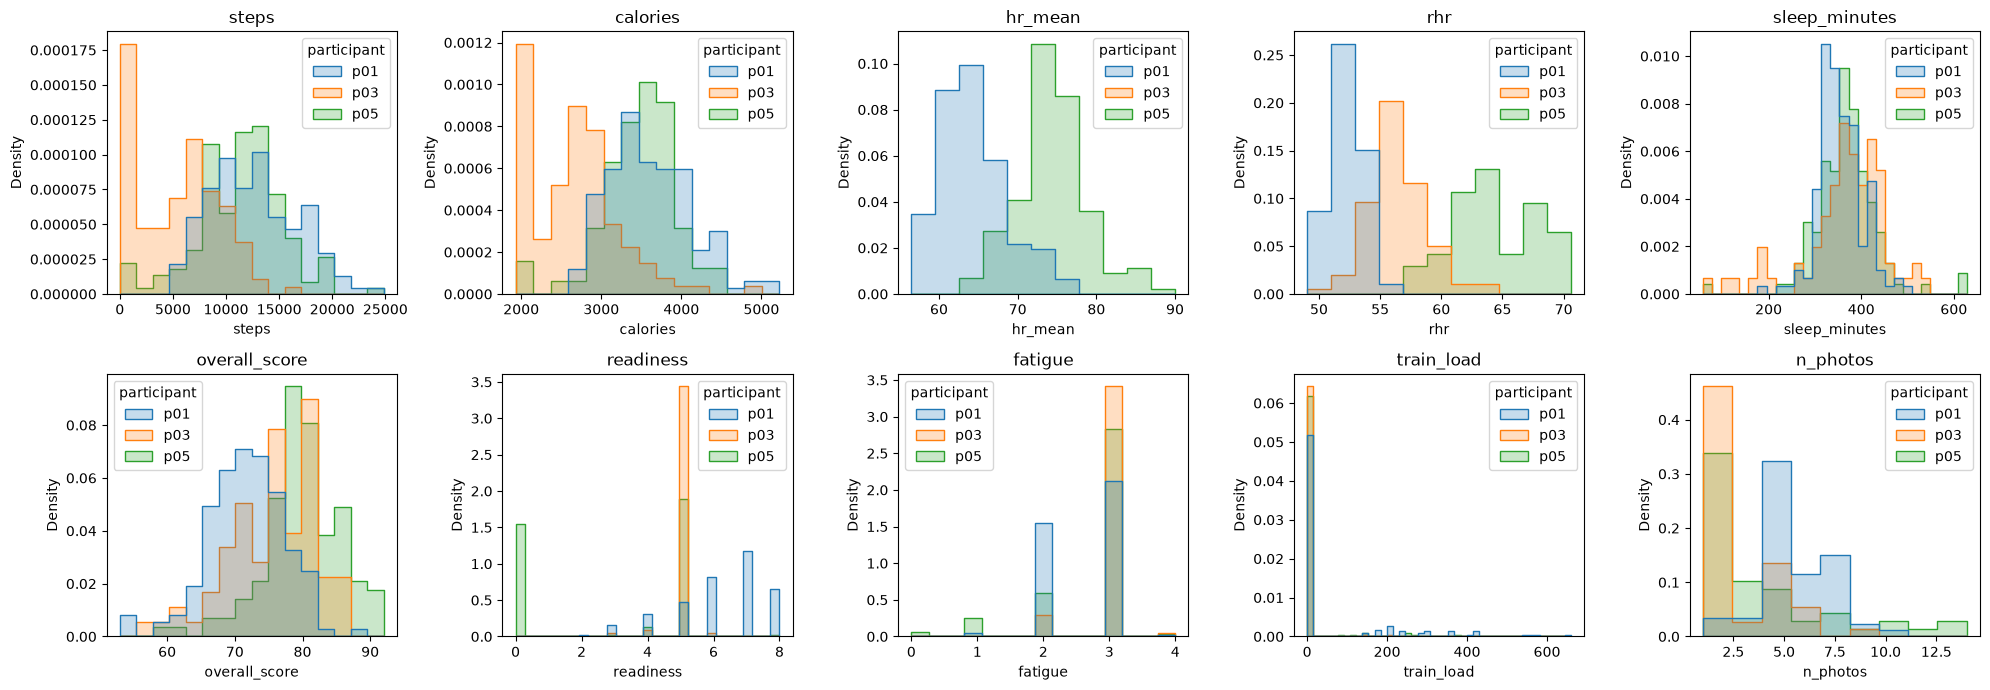

In [5]:
fig, axes = plt.subplots(2, 5, figsize=(20, 7))
for ax, col in zip(axes.flat, principales):
    sns.histplot(data=df, x=col, hue="participant", ax=ax, element="step", stat="density", common_norm=False)
    ax.set_title(col)
plt.tight_layout()
plt.show()


In [6]:
df[(df["participant"] == "p03") & (df["steps"] < 1000)][["date", "steps", "calories", "zone_below", "zone_fatburn"]]

,date,steps,calories,zone_below,zone_fatburn
154,2019-11-03,0.0,1944.13,NaN,NaN
164,2019-11-13,13.0,1959.50,430.0,2.0
167,2019-11-16,394.0,2059.00,546.0,8.0
191,2019-12-10,195.0,1929.60,460.0,80.0
196,2019-12-15,31.0,1933.12,NaN,NaN
199,2019-12-18,633.0,2024.02,127.0,0.0
200,2019-12-19,6.0,1933.92,21.0,0.0
208,2019-12-27,33.0,1963.13,109.0,0.0
213,2020-01-01,904.0,2110.10,890.0,1.0
223,2020-01-11,7.0,1940.01,630.0,0.0


In [7]:
#p03 a beaucoup de jour à moins de 1 000 pas avec environ 2000 calories 

In [8]:
zones = ["zone_below", "zone_fatburn", "zone_cardio", "zone_peak"]
df["port_min"] = df[zones].sum(axis=1, min_count=1)
df.groupby("participant")["port_min"].describe()

,count,mean,std,min,25%,50%,75%,max
participant,,,,,,,,
p01,152.0,1372.375000,104.404005,605.0,1381.25,1409.0,1417.0,1436.0
p03,117.0,909.076923,349.492814,7.0,687.00,985.0,1168.0,1409.0
p05,145.0,1315.882759,220.779349,24.0,1342.00,1382.0,1416.0,1439.0


In [9]:
(df["port_min"] < 600).groupby(df["participant"]).sum()

participant
p01     0
p03    22
p05     5
Name: port_min, dtype: int64

In [10]:
df.groupby("participant")["readiness"].value_counts().unstack(fill_value=0)

readiness,0.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0
participant,,,,,,,,
p01,0,1,6,12,18,31,45,25
p03,0,0,1,2,74,1,0,0
p05,57,0,1,5,70,0,0,1


In [11]:
# Avec p01 on a beaucoup d'information ses réponses vont de 2 à 8 
# p03 répond 5 dans  74 des cas sur 77
# p05 répond 5 dans 70 des cas et 0 dans 57 des cas

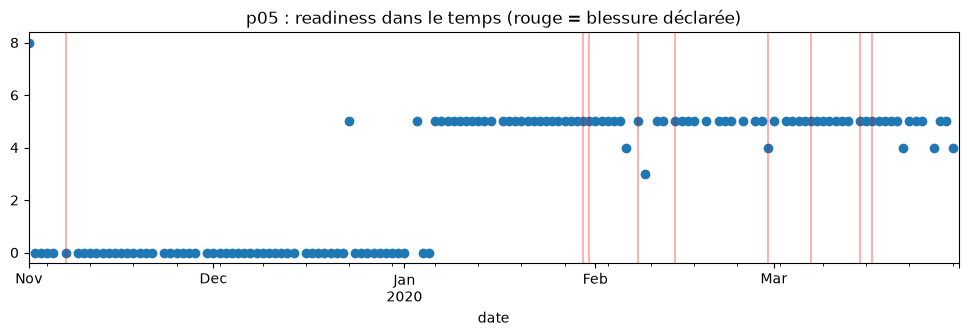

In [12]:
p05 = df[df["participant"] == "p05"].set_index("date")
ax = p05["readiness"].plot(marker="o", linestyle="", figsize=(12, 3))
for d in p05[p05["injured"] == 1].index:
    ax.axvline(d, color="red", alpha=0.3)
ax.set_title("p05 : readiness dans le temps (rouge = blessure déclarée)")
plt.show()

In [13]:
# Résultat étrange de 2 bloc avec une grosse coupure , sans lien avec une blessure , soit un problème de l'application , sois une modification de l'application j'imagine

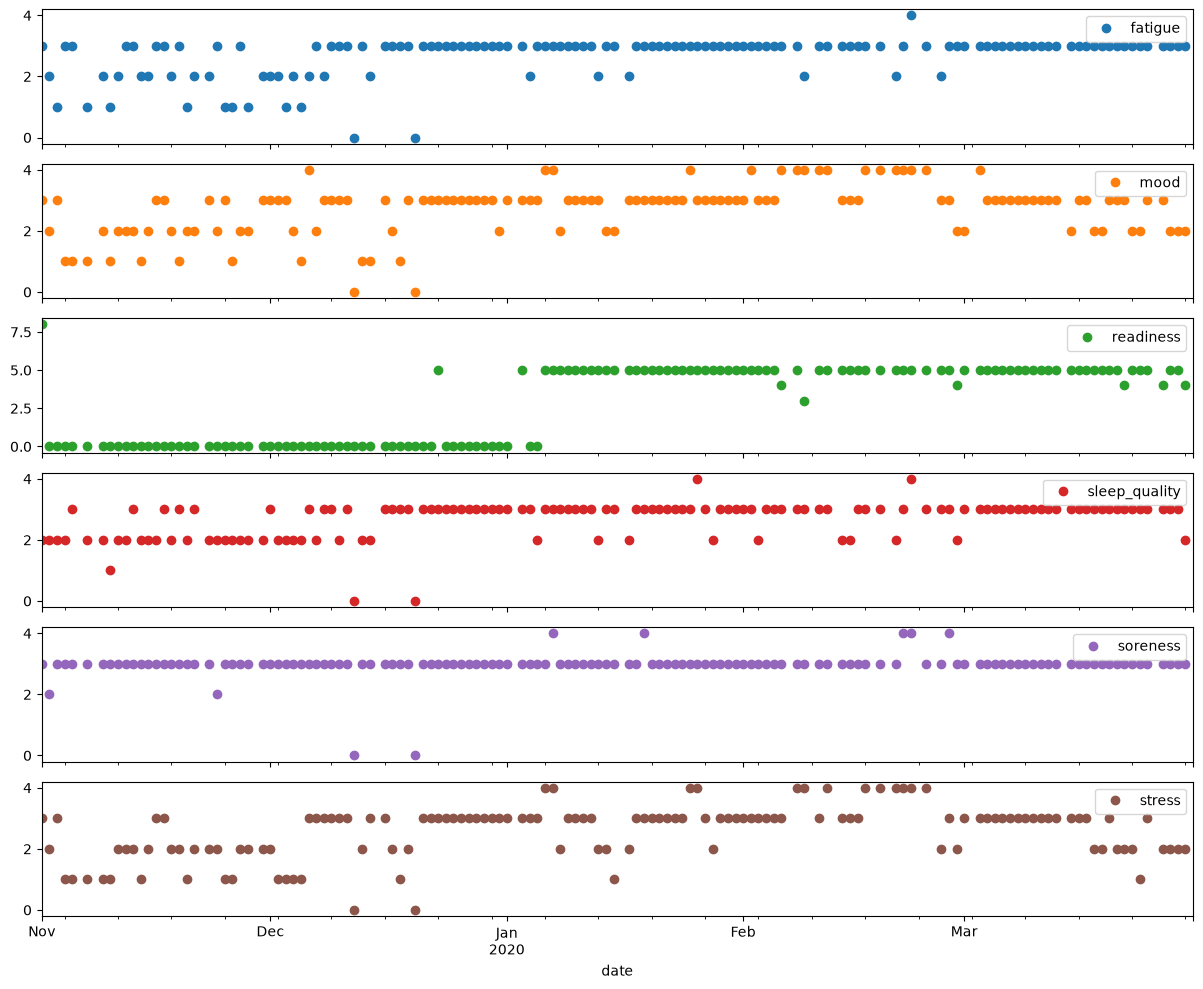

In [14]:
wellness = ["fatigue", "mood", "readiness", "sleep_quality", "soreness", "stress"]
p05[wellness].plot(subplots=True, marker="o", linestyle="", figsize=(12, 10), legend=True)
plt.tight_layout()
plt.show()

In [15]:
cols_1_5 = ["fatigue", "mood", "sleep_quality", "soreness", "stress"]
(df[cols_1_5] == 0).groupby(df["participant"]).sum()

,fatigue,mood,sleep_quality,soreness,stress
participant,,,,,
p01,0,0,0,0,0
p03,0,0,0,0,0
p05,2,2,2,2,2


In [16]:
#p05 : deux jours en décembre avec des 0 partout alors que l'échelle va de 1 à 5-> saisies invalides ou NaN

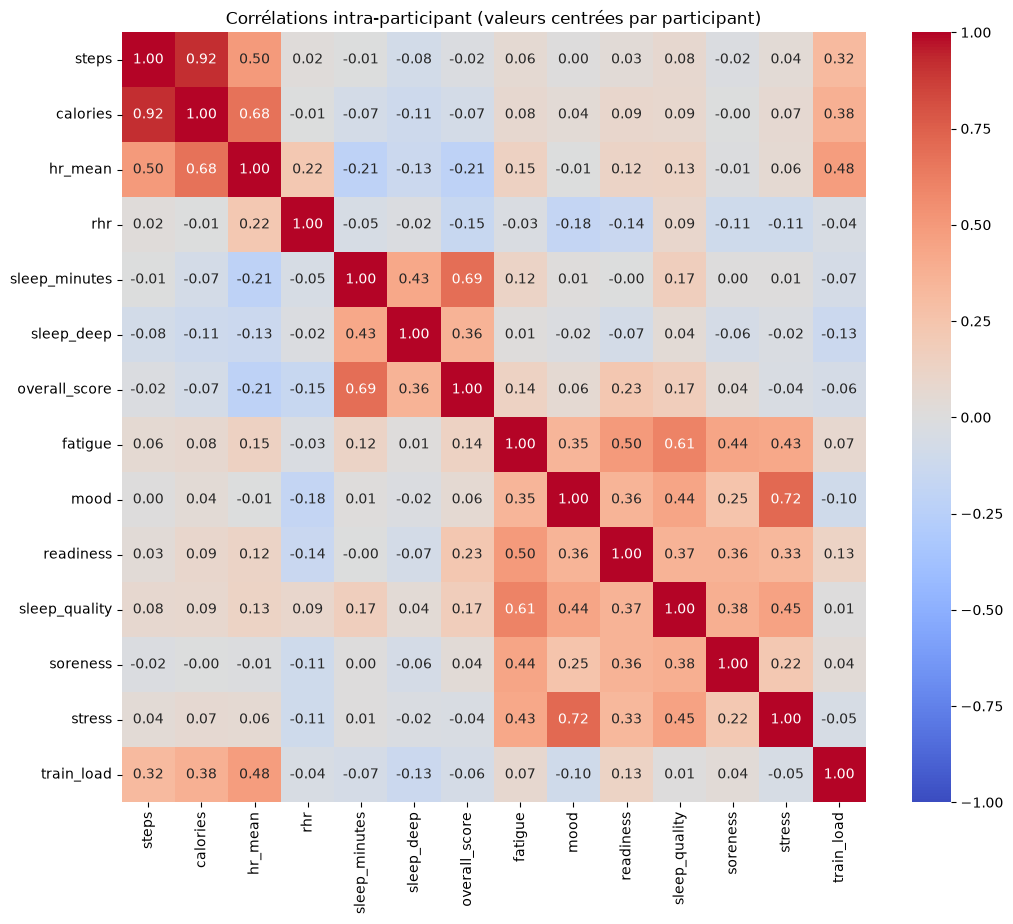

In [17]:
cols = ["steps", "calories", "hr_mean", "rhr", "sleep_minutes", "sleep_deep", "overall_score",
        "fatigue", "mood", "readiness", "sleep_quality", "soreness", "stress", "train_load"]

centre = df[cols] - df.groupby("participant")[cols].transform("mean")

plt.figure(figsize=(12, 10))
sns.heatmap(centre.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Corrélations intra-participant (valeurs centrées par participant)")
plt.show()

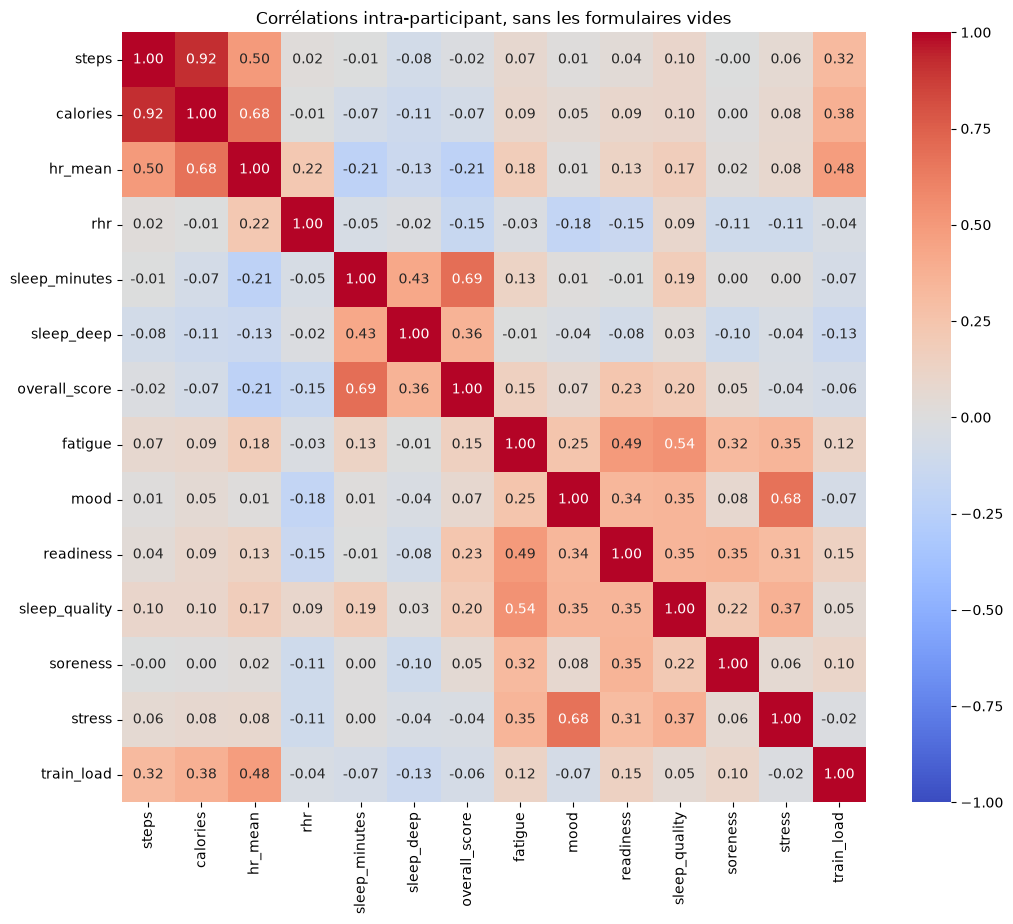

In [18]:
df_verif = df.copy()
tout_zero = (df_verif[cols_1_5] == 0).all(axis=1)
df_verif.loc[tout_zero, cols_1_5 + ["readiness"]] = float("nan")

centre = df_verif[cols] - df_verif.groupby("participant")[cols].transform("mean")
plt.figure(figsize=(12, 10))
sns.heatmap(centre.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Corrélations intra-participant, sans les formulaires vides")
plt.show()

In [19]:
# On voit bien que sans les formulaires vides , les corrélations du questionnaire baissent tout en restant positive

In [20]:
# Ce qu'on aura à faire pour le nettoyage :
    #Types (float, échelles ..)
    #Jour de port ( variable d'activité à passer en NaN
    #p03 : Jours a 0 pas avec calories estimées
    #Formulaire vide de p05
    #Readiness non fiable pour p03 (quasi toujours 5) et p05 (0 puis 5)
    #FC min/max extrêmes
    #Redondances: pas/distance, pas/calories, score global/sous-scores
    #Valeurs manquantes
